### Black-Scholes Consistency Checks

This notebook validates several theoretical consistency properties of Black-Scholes option pricing:

- Put-call parity
- Strike monotonicity
- Convexity in strike
- Digital option replication via call spreads

In [1]:
import sys
sys.path.insert(0, './../src')

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [30]:
S = 100
T = 1
r = 0.05
d = 0.02
sigma = 0.2
strikes = np.linspace(50,160, 100)

In [31]:
strikes

array([ 50.        ,  51.11111111,  52.22222222,  53.33333333,
        54.44444444,  55.55555556,  56.66666667,  57.77777778,
        58.88888889,  60.        ,  61.11111111,  62.22222222,
        63.33333333,  64.44444444,  65.55555556,  66.66666667,
        67.77777778,  68.88888889,  70.        ,  71.11111111,
        72.22222222,  73.33333333,  74.44444444,  75.55555556,
        76.66666667,  77.77777778,  78.88888889,  80.        ,
        81.11111111,  82.22222222,  83.33333333,  84.44444444,
        85.55555556,  86.66666667,  87.77777778,  88.88888889,
        90.        ,  91.11111111,  92.22222222,  93.33333333,
        94.44444444,  95.55555556,  96.66666667,  97.77777778,
        98.88888889, 100.        , 101.11111111, 102.22222222,
       103.33333333, 104.44444444, 105.55555556, 106.66666667,
       107.77777778, 108.88888889, 110.        , 111.11111111,
       112.22222222, 113.33333333, 114.44444444, 115.55555556,
       116.66666667, 117.77777778, 118.88888889, 120.  

In [32]:
import black_scholes

In [36]:
call_prices = black_scholes.call_price(S,strikes, T,r,d,sigma)
put_prices = black_scholes.put_price(S,strikes, T,r,d,sigma)

In [37]:
call_prices

array([50.45889478, 49.40225988, 48.34576494, 47.28946623, 46.23343769,
       45.17777474, 44.1225985 , 43.06806022, 42.01434594, 40.96168119,
       39.91033555, 38.860627  , 37.81292584, 36.76765805, 35.72530785,
       34.6864195 , 33.65159802, 32.62150883, 31.59687632, 30.57848113,
       29.5671564 , 28.56378279, 27.56928248, 26.58461223, 25.61075563,
       24.64871466, 23.69950073, 22.76412545, 21.8435912 , 20.93888174,
       20.05095303, 19.18072443, 18.32907035, 17.49681265, 16.68471365,
       15.89347012, 15.12370807, 14.37597853, 13.65075431, 12.94842775,
       12.26930936, 11.61362747, 10.98152874, 10.37307944,  9.78826755,
        9.22700551,  8.68913354,  8.17442353,  7.6825833 ,  7.21326121,
        6.76605107,  6.34049718,  5.93609946,  5.55231872,  5.18858175,
        4.84428649,  4.51880689,  4.21149776,  3.92169934,  3.64874155,
        3.39194816,  3.15064048,  2.92414092,  2.71177613,  2.51287993,
        2.32679589,  2.15287962,  1.99050076,  1.83904476,  1.69

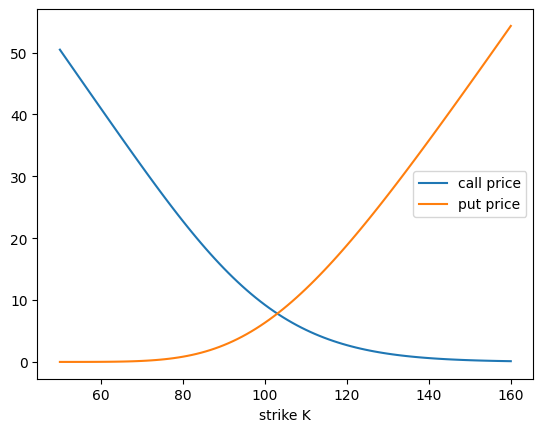

In [42]:
plt.plot(strikes, call_prices, label='call price')
plt.plot(strikes, put_prices, label='put price')
plt.legend()
# plt.ylabel('call prices Spot=100')
plt.xlabel('strike K')
plt.show()

#### Put-Call Parity
$$ C-P = Se^{-dT} - Ke^{-rT} $$

In [45]:
error = call_prices - put_prices - (S*np.exp(-d*T)-strikes*np.exp(-r*T))

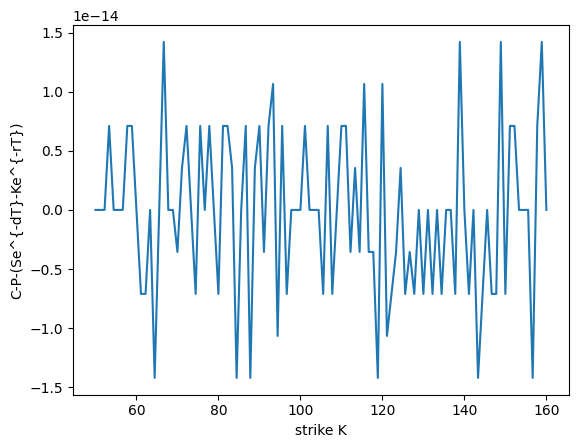

In [48]:
plt.plot(strikes, error)
plt.xlabel('strike K')
plt.ylabel('C-P-(Se^{-dT}-Ke^{-rT})')
plt.show()

In [57]:
# The parity residual remains numerically close to zero across strikes, 
# confirming consistency with the put-call parity identity under Black-Scholes assumptions.

# Mean error
np.mean(error)

-2.842170943040401e-16

#### Digital Option Analysis over analytical formula

In [110]:
epsilons = np.linspace(5, 1e-12, 50)
K = 100

In [111]:
CK = black_scholes.call_price(S,K, T,r,d,sigma)
call_prices = black_scholes.call_price(S,K+epsilons, T,r,d,sigma)

In [112]:
dC_by_dK = (call_prices-CK)/epsilons

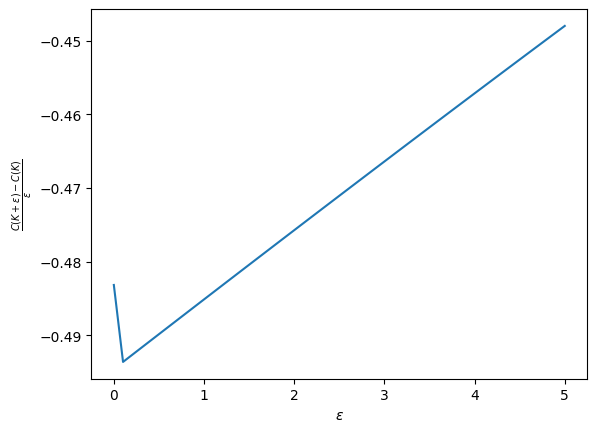

In [113]:
plt.plot(epsilons, dC_by_dK)
plt.xlabel(r"$\epsilon$")
plt.ylabel(r"$\frac{C(K+\epsilon)-C(K)}{\epsilon}$")
plt.show()

In [114]:
analytical_digital_call_price = black_scholes.digital_call_price(S,K, T,r,d,sigma)

In [115]:
analytical_digital_call_price

0.49458109105322356

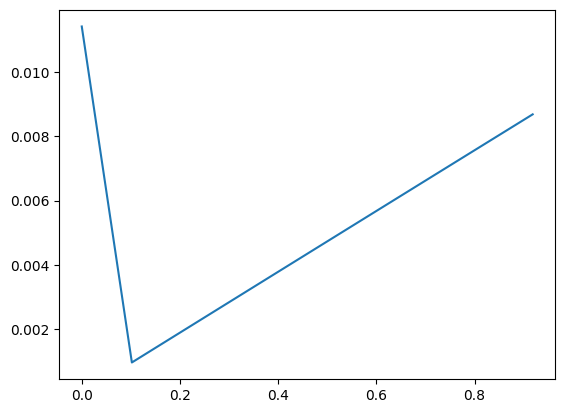

In [116]:
# absolute error vs epsilon
plt.plot(epsilons[-10:], np.abs(-dC_by_dK[-10:]-analytical_digital_call_price))

In [ ]:
# Instability occurs due to floating point errors